## Ayudantía 2
### Profesor: Elwin van 't Wout
### Ayudante: Alberto Almuna Morales (alberto.almuna@uc.cl)

Se propone el siguiente ejemplo a paralelizar utilizando Joblib:

In [6]:
import time as tm
import numpy as np

Utilizaremos la [fórmula de Haversine](https://en.wikipedia.org/wiki/Haversine_formula) para calcular distancias dadas las latitudes y longitudes de puntos:

In [7]:
def calculateHaversineDistance(latitude1, longitude1, latitude2, longitude2):
    earth_radius_km = 6371

    # Pasamos a radianes:
    latitude_dist = (latitude2 - latitude1) * np.pi / 180
    longitude_dist = (longitude2 - longitude1) * np.pi / 180

    # Aplicamos la fórmula:
    haversine_value = np.sin(latitude_dist / 2)**2 + \
        np.sin(longitude_dist / 2)**2
    haversine_value *= np.cos(latitude1 * np.pi / 180) * \
        np.cos(latitude2 * np.pi / 180)

    haversine_dist = 2 * \
        np.arcsin(np.sqrt(haversine_value)) * earth_radius_km

    return haversine_dist

Código secuencial:

In [10]:
t0 = tm.time()

coordinates = []
max_distance = -1

with open("coordenadas10000.txt", 'r') as file:

    file.readline()

    for line in file:

        coordinates_info = line.strip().split(',')
        latitude = float(coordinates_info[0])
        longitude = float(coordinates_info[1])

        coordinates.append((latitude, longitude))


for coordinate1 in coordinates:
    for coordinate2 in coordinates:

        distance = calculateHaversineDistance(
            coordinate1[0], coordinate1[1], coordinate2[0], coordinate2[1])

        if distance > max_distance:
            max_distance = distance


t1 = tm.time()


print('Tiempo de ejecucion: ', t1-t0)
print('Distancia maxima: ', max_distance)

Tiempo de ejecucion:  589.8582360744476
Distancia maxima:  44.829257919253564


Propuesta código paralelo:

In [17]:
import time as tm
import numpy as np
from joblib import Parallel
from joblib import delayed

In [18]:
def readData(line):
    coordinates_info = line.strip().split(',')
    latitude = float(coordinates_info[0])
    longitude = float(coordinates_info[1])
    return (latitude, longitude)

In [19]:
def calculateDistances(coordinate1, original):
    max_distance = -1

    for coordinate2 in original:

        distance = calculateHaversineDistance(
            coordinate1[0], coordinate1[1], coordinate2[0], coordinate2[1])

        if distance > max_distance:
            max_distance = distance
    return max_distance

In [20]:
t0 = tm.time()
workers = 8

with open("coordenadas10000.txt", 'r') as file:
    # Leemos el archivo:
    file.readline() # Nos saltamos la primera línea
    file = file.readlines()

    # Creamos y ejecutamos los procesos paralelos:

    # Primero hacemos la lectura de la información:
    parallel_pool = Parallel(n_jobs=workers)
    parallel_readData = delayed(readData)
    parallel_tasks1 = map(parallel_readData, file)
    parallel_results1 = parallel_pool(parallel_tasks1)

    # Luego los cálculos de distancias
    parallel_calculateDistances = delayed(calculateDistances)
    parallel_tasks2 = [parallel_calculateDistances(i, parallel_results1) for i in parallel_results1]
    parallel_results2 = parallel_pool(parallel_tasks2)
    max_distance = max(parallel_results2)

t1 = tm.time()

# Imprimimos las estadísticas:
print('Tiempo de ejecucion: ', t1-t0)
print('Distancia maxima: ', max_distance)

Tiempo de ejecucion:  109.49356174468994
Distancia maxima:  44.829257919253564


Veamos un gráfico de tiempo de cómputo versus el número de trabajadores:

In [25]:
# Revisamos nuestro cpu_count

from joblib import cpu_count
print("Number of cores found by joblib:", cpu_count())

Number of cores found by joblib: 16


Creemos una función con nuestro proceso paralelo:

In [23]:
def parallelProcess(workers, nombre_archivo):
    with open(nombre_archivo, 'r') as file:
        # Leemos el archivo:
        file.readline() # Nos saltamos la primera línea
        file = file.readlines()

        # Creamos y ejecutamos los procesos paralelos:

        # Primero hacemos la lectura de la información:
        parallel_pool = Parallel(n_jobs=workers)
        parallel_readData = delayed(readData)
        parallel_tasks1 = map(parallel_readData, file)
        parallel_results1 = parallel_pool(parallel_tasks1)

        # Luego los cálculos de distancias
        parallel_calculateDistances = delayed(calculateDistances)
        parallel_tasks2 = [parallel_calculateDistances(i, parallel_results1) for i in parallel_results1]
        parallel_results2 = parallel_pool(parallel_tasks2)
        max_distance = max(parallel_results2)
    return max_distance

Y hacemos el gráfico:

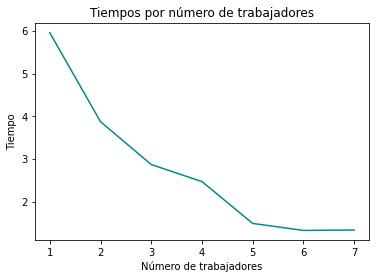

In [27]:
import matplotlib.pyplot as plt

workers_list = [i for i in range(1, 41)]
time_results = []

for workers in workers_list:
    t0 = tm.time()

    parallelProcess(workers, "coordenadas1000.txt")

    t1 = tm.time()

    # Guardamos el tiempo en la lista:
    time_results.append(t1-t0)

# Graficamos:
plt.plot(workers_list, time_results, color="darkcyan")
plt.title("Tiempos por número de trabajadores")
plt.xlabel("Número de trabajadores")
plt.ylabel("Tiempo")
plt.show()

Algunos cálculos de eficiencia paralela que verán más adelante en el curso:

- Speedup: $S_p=T_1/T_p$ con $T_p$ el tiempo de ejecución de los $p$ procesadores.

In [31]:
Sp = [time_results[0]/i for i in time_results]
Sp

[1.0,
 1.536431665719442,
 2.0714655274747673,
 2.4045244239800847,
 3.9743643041026884,
 4.459632224355787,
 4.4294124408391236]

- Eficiencia: $E_p=S_p/p$

In [33]:
Ep = [Sp[i-1]/i for i in range(1, len(time_results)+1)]
Ep

[1.0,
 0.768215832859721,
 0.6904885091582558,
 0.6011311059950212,
 0.7948728608205377,
 0.7432720373926313,
 0.6327732058341605]